In [38]:
import fsrs
from datetime import datetime, timezone
import json
from tqdm import tqdm
from collections import defaultdict
# https://raw.githubusercontent.com/open-spaced-repetition/srs-benchmark/0f70abe71ede66e27ee4c392a72998695ebc48b1/result/FSRS-6.jsonl
with open("FSRS-6-unclamped-decay.jsonl") as f:
    users = [json.loads(s) for s in f.readlines()]

dr = 0.7

In [47]:
example_ratings = [tuple(a) for a in [
    [3, 3, 3, 3],
    [3, 3],
    [1, 3, 3, 3],
    [1, 3],
    [1],
    [2],
    [3],
    [4]
]]

decay_bins = defaultdict(lambda: [])

for user in tqdm(users):
    params = user["parameters"]["0"]
    decay = params[20]

    sched = fsrs.Scheduler(params, learning_steps=(), relearning_steps=())
    sched.desired_retention = dr

    for ratings in example_ratings:
        card = fsrs.Card()
        now = datetime.now(timezone.utc)
        for rating in ratings:
            last_review = now
            card, _ = sched.review_card(card, rating, now)
            now = card.due
        total_time = now - last_review
        decay_bins[ratings].append((decay, total_time.days))
        

    

100%|██████████| 9999/9999 [01:28<00:00, 113.11it/s]


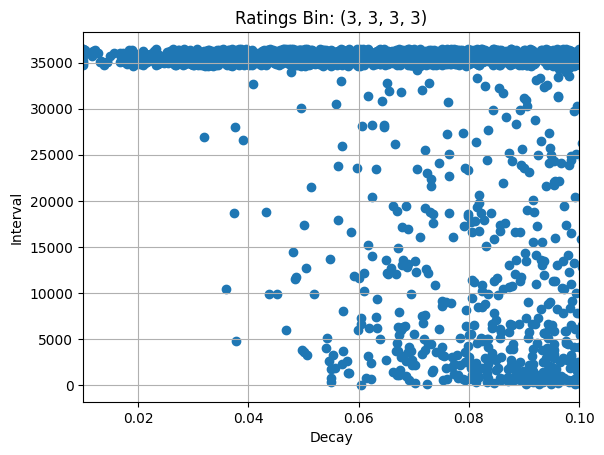

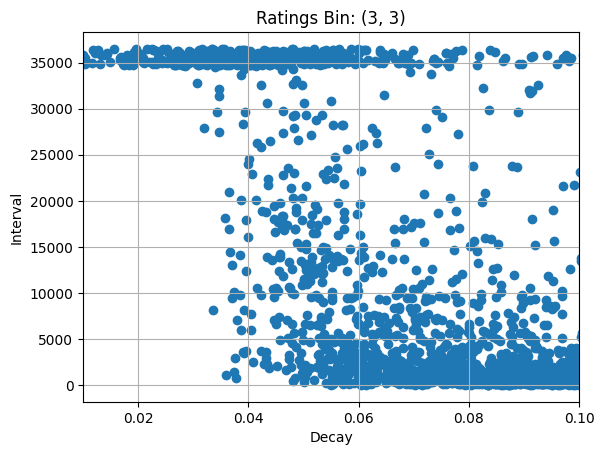

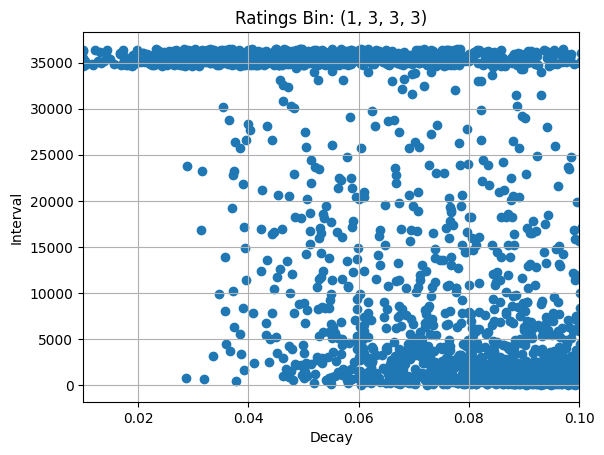

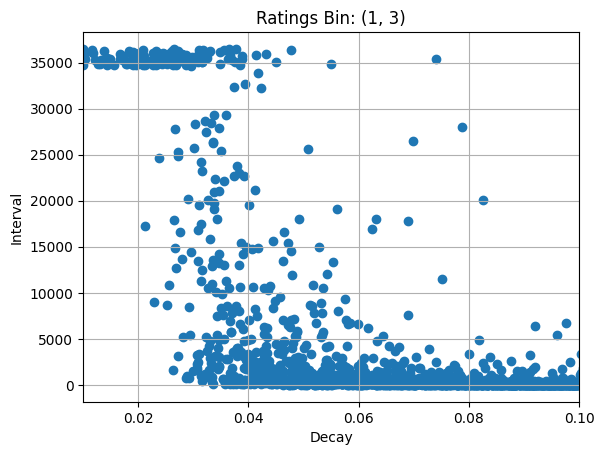

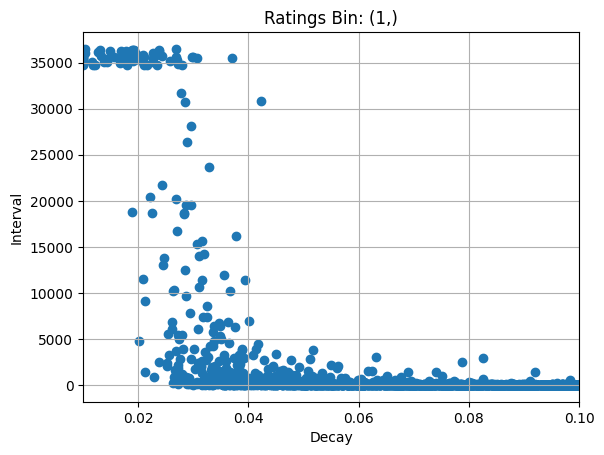

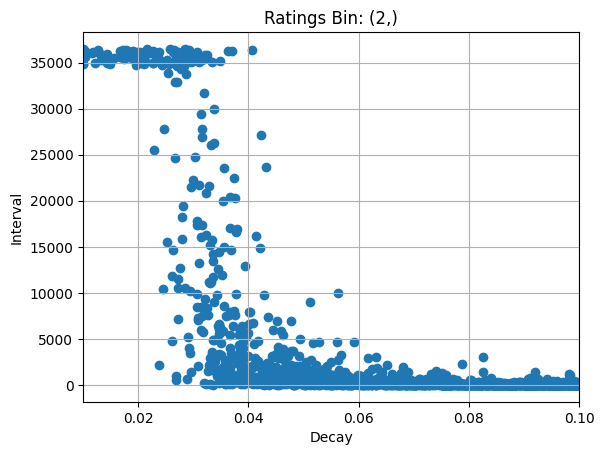

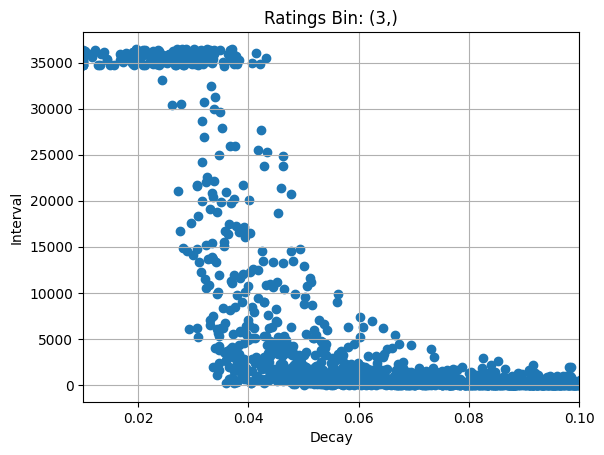

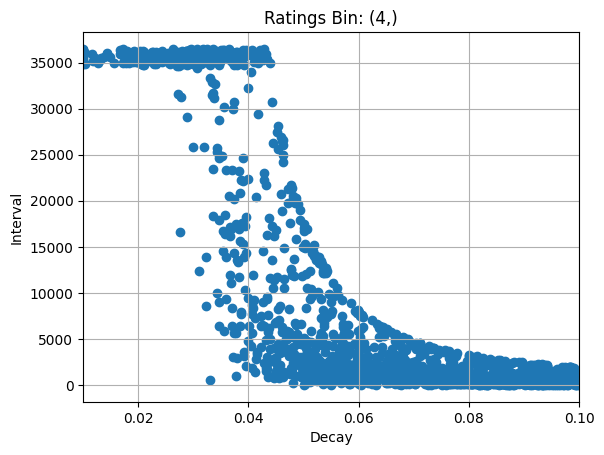

In [63]:
from matplotlib import pyplot as plt
import numpy as np

max_displayed_decay = 0.1

for decay_bin, ratings in decay_bins.items():
    decays, intervals = zip(*ratings)

    plt.figure()  # 👈 creates a new figure
    plt.scatter(decays, intervals)
    plt.title(f"Ratings Bin: {decay_bin}")
    plt.xlabel("Decay")
    plt.xlim((0.01, max_displayed_decay))
    plt.ylabel("Interval")
    plt.grid(True)
    plt.show()  # 👈 ensures it displays in notebook
